# Titanic Survival prediction 泰坦尼克號生還者預測
本專題將以泰坦尼克號乘客資料為基礎，建立分類模型來預測乘客是否能夠生還。  
接下來將依序進行資料清理、特徵選擇、缺失值處理與數值編碼，並使用多種機器學習演算法進行分析與比較。

本研究將先以 Decision Tree 作為基礎模型，接著延伸至 Logistic Regression、Random Forest、SVM 等方法，觀察不同模型在準確率、ROC-AUC、混淆矩陣與分類報告上的表現差異。  
最後將綜合比較各模型的預測能力，找出較適合此資料集的分類方法。

### Decision Tree 分析

在本節中，我們先使用 Decision Tree 來建立泰坦尼克號生還者預測模型。  
Decision Tree 的優點是結構清楚、容易解釋，能快速看出哪些特徵對生還結果影響較大，因此適合作為本研究的基礎模型與比較基準。

本節將依序完成資料前處理、特徵編碼、模型訓練、預測與評估，並透過準確率、ROC-AUC、混淆矩陣、分類報告與特徵重要度來觀察模型表現。  
同時也會視覺化決策樹，方便理解模型的判斷規則。

原始欄位: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']
可用資料筆數: 1309
Accuracy: 0.7481
ROC-AUC: 0.7565
Confusion Matrix:
 [[166  28]
 [ 38  30]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8137    0.8557    0.8342       194
           1     0.5172    0.4412    0.4762        68

    accuracy                         0.7481       262
   macro avg     0.6655    0.6484    0.6552       262
weighted avg     0.7368    0.7481    0.7413       262



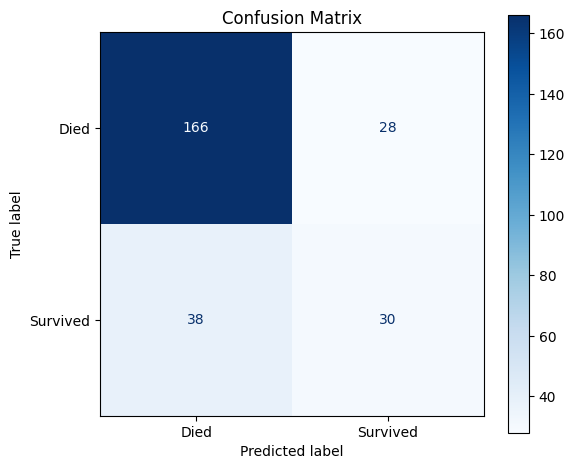

Feature Importance:
     Feature  Importance
0       Sex    0.570763
1    Pclass    0.228878
2       Age    0.149915
3      Fare    0.049633
4     SibSp    0.000811
5     Parch    0.000000
6  Embarked    0.000000


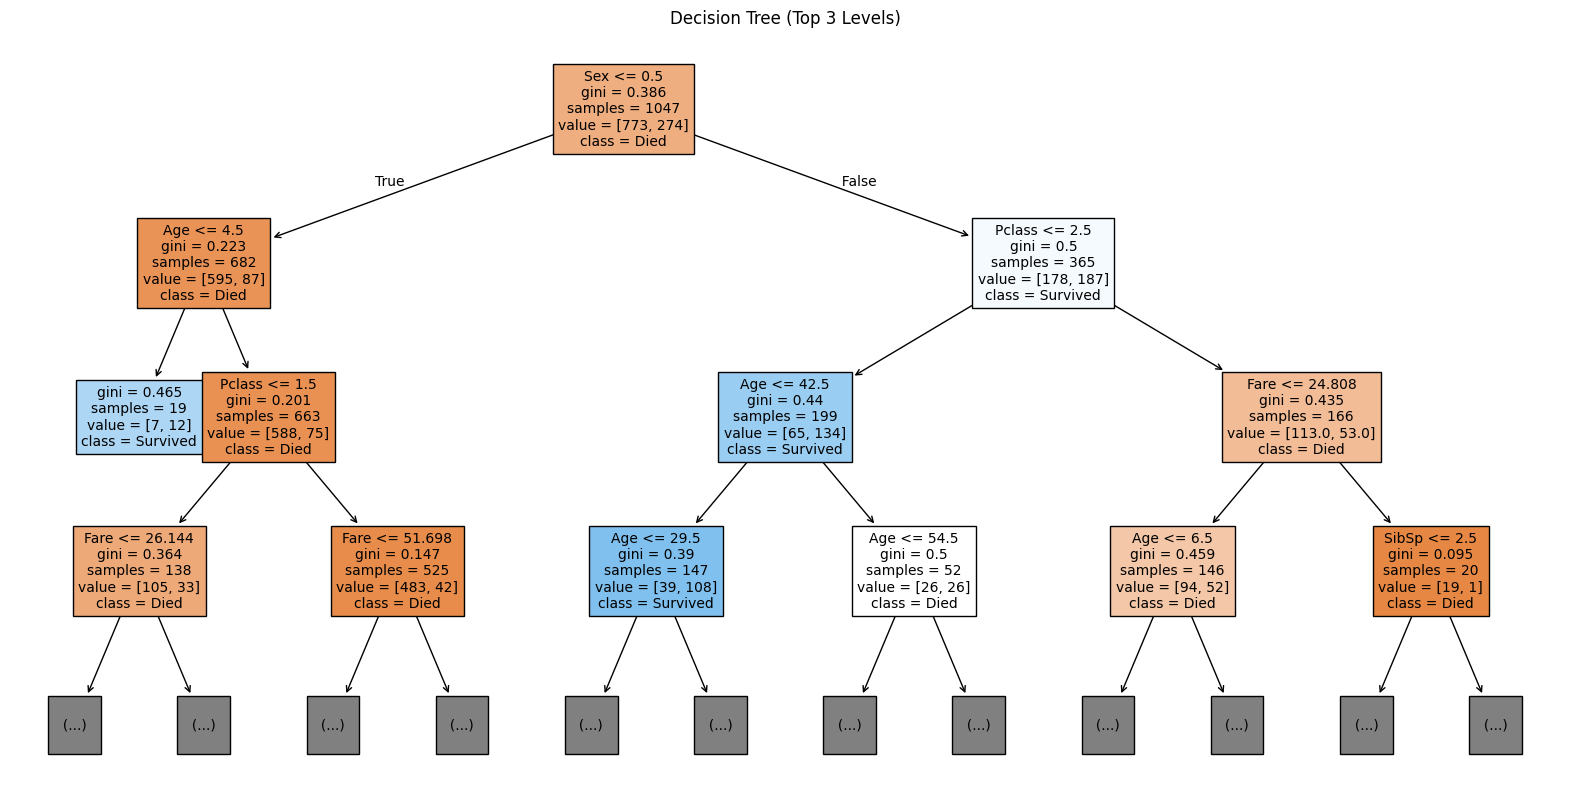

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    )

# =========================
# 1. 讀資料
# =========================
df = pd.read_csv("titanic.csv")
print("原始欄位:", df.columns.tolist())

# =========================
# 2. 清理欄位 + 欄位標準化
# =========================

# 刪掉所有叫 zero 的欄位
df = df.loc[:, ~df.columns.str.contains(r"^zero", case=False)]

# 修正常見欄位名稱（不同 Titanic 版本名稱可能不同）
rename_map = {
    "2urvived": "Survived",
    "sibsp": "SibSp",
}
df = df.rename(columns=rename_map)

# =========================
# 3. 檢查必要欄位
# =========================
required_cols = ["Age", "Fare", "Sex", "SibSp", "Parch", "Pclass", "Embarked", "Survived"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"缺少必要欄位: {missing}，目前欄位: {df.columns.tolist()}")

# =========================
# 4. 處理缺失值
# =========================
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# =========================
# 5. 類別轉數值（兼容文字版/數值版）
# =========================

# Sex: 文字版 male/female -> 0/1；若已是數值則直接使用
if df["Sex"].dtype == "object":
    df["Sex"] = df["Sex"].astype(str).str.lower().map({"male": 0, "female": 1})
else:
    df["Sex"] = pd.to_numeric(df["Sex"], errors="coerce")

# Embarked: 文字版 S/C/Q -> 0/1/2；若已是數值則直接使用
if df["Embarked"].dtype == "object":
    emb_upper = df["Embarked"].astype(str).str.upper()
    mapped = emb_upper.map({"S": 0, "C": 1, "Q": 2})
    numeric = pd.to_numeric(df["Embarked"], errors="coerce")
    df["Embarked"] = mapped.fillna(numeric)
else:
    df["Embarked"] = pd.to_numeric(df["Embarked"], errors="coerce")

# Target 轉整數
df["Survived"] = pd.to_numeric(df["Survived"], errors="coerce")

# 移除無法解析的資料
df = df.dropna(subset=["Sex", "Embarked", "Survived"]).copy()
df["Sex"] = df["Sex"].astype(int)
df["Embarked"] = df["Embarked"].astype(int)
df["Survived"] = df["Survived"].astype(int)
print("可用資料筆數:", len(df))

# =========================
# 6. 選特徵
# =========================
features = ["Age", "Fare", "Sex", "SibSp", "Parch", "Pclass", "Embarked"]
X = df[features]
y = df["Survived"]

# =========================
# 7. 切資料（分類建議用 stratify）
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 8. 建模型
# =========================
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)
model.fit(X_train, y_train)

# =========================
# 9. 預測與評估
# =========================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))

# 混淆矩陣可視化
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

# =========================
# 10. 特徵重要度
# =========================
importance_df = (
    pd.DataFrame({"Feature": features, "Importance": model.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
print("Feature Importance:\n", importance_df)

# =========================
# 11. 畫 Tree
# =========================
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=features,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()

### Logistic Regression 分析

本節將使用 Logistic Regression 建立泰坦尼克號生還預測模型。  
Logistic Regression 是適合二元分類的經典方法，能夠輸出生還機率，並清楚分析各特徵對結果的影響方向。

在這裡，它的角色主要是作為一個簡潔、穩定且可解釋的比較模型，與 Decision Tree、Random Forest、SVM 的結果進行對照。

可用資料筆數: 1309
Accuracy: 0.7519
ROC-AUC: 0.7592
Confusion Matrix:
 [[172  22]
 [ 43  25]]
Classification Report:
               precision    recall  f1-score   support

           0     0.8000    0.8866    0.8411       194
           1     0.5319    0.3676    0.4348        68

    accuracy                         0.7519       262
   macro avg     0.6660    0.6271    0.6379       262
weighted avg     0.7304    0.7519    0.7356       262



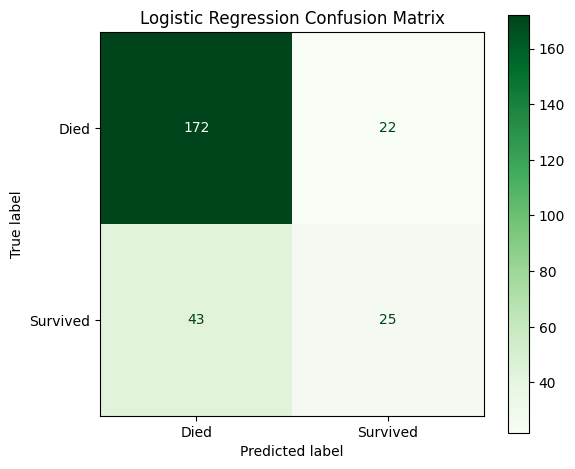

Logistic Regression Coefficients:
    Feature  Coefficient
0       Sex     0.930184
1    Pclass    -0.734823
2       Age    -0.420661
3     SibSp    -0.163537
4      Fare    -0.060659
5  Embarked    -0.033051
6     Parch    -0.012896


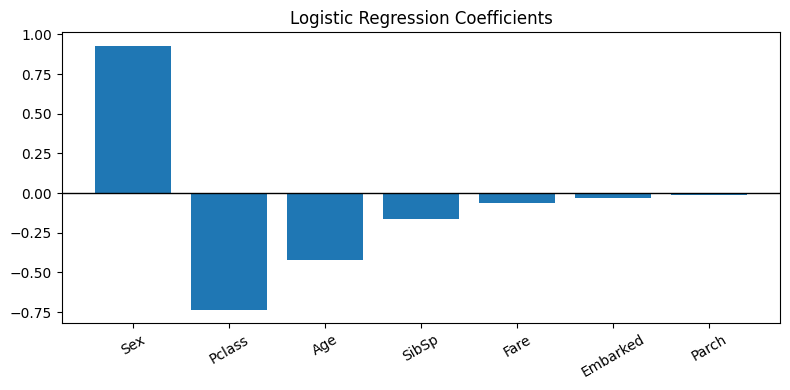

Prediction Result (Top 20):
       Age      Fare  Sex  SibSp  Parch  Pclass  Embarked  Actual  Predicted  \
956   28.0   21.0000    1      0      0       2         2       0          1   
572   36.0   26.3875    0      0      0       1         2       1          0   
243   22.0    7.1250    0      0      0       3         2       0          0   
396   31.0    7.8542    1      0      0       3         2       0          0   
1028  26.0   13.0000    0      0      0       2         2       0          0   
1108  57.0  164.8667    0      1      1       1         2       0          0   
1032  33.0  151.5500    1      0      0       1         2       0          1   
751    6.0   12.4750    0      0      1       3         2       1          0   
414   44.0    7.9250    0      0      0       3         2       1          0   
824    2.0   39.6875    0      4      1       3         2       0          0   
749   31.0    7.7500    0      0      0       3         1       0          0   
907   35.0  

C:\Users\jack6\AppData\Local\Temp\ipykernel_23628\2526628335.py:152: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jack6\AppData\Local\Temp\ipykernel_23628\2526628335.py:152: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jack6\AppData\Local\Temp\ipykernel_23628\2526628335.py:152: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jack6\AppData\Local\Temp\ipykernel_23628\2526628335.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jack6\AppData\Local\Temp\ipykernel_23628\2526628335.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jack6\AppData\Local\Temp\ipykernel_23628\2526628335.py:152: UserWarning: Glyph 24

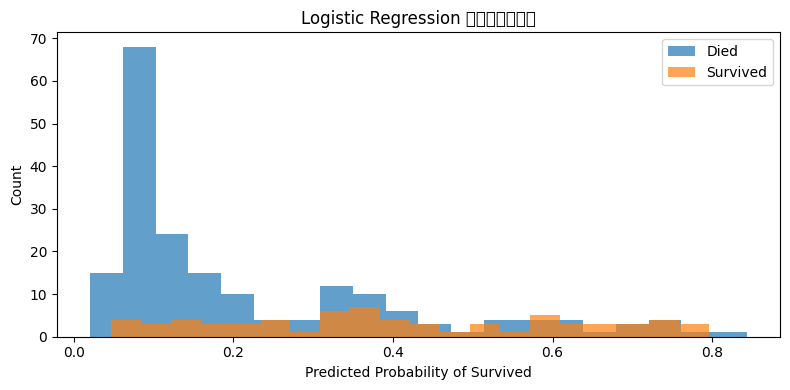

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# =========================
# 1. 準備資料
# =========================

# 若前一節已經建立好 df，就直接沿用；否則在此獨立完成資料前處理
try:
    df_lr = df.copy()
except NameError:
    df_lr = pd.read_csv("titanic.csv", encoding="utf-8")
    df_lr = df_lr.loc[:, ~df_lr.columns.str.contains(r"^zero", case=False)]
    df_lr = df_lr.rename(columns={
        "2urvived": "Survived",
        "sibsp": "SibSp",
    })

    # 缺失值處理
    df_lr["Age"] = df_lr["Age"].fillna(df_lr["Age"].median())
    df_lr["Fare"] = df_lr["Fare"].fillna(df_lr["Fare"].median())
    df_lr["Embarked"] = df_lr["Embarked"].fillna(df_lr["Embarked"].mode()[0])

    # Sex: 文字版 / 數值版都相容
    if df_lr["Sex"].dtype == "object":
        df_lr["Sex"] = df_lr["Sex"].astype(str).str.lower().map({"male": 0, "female": 1})
    else:
        df_lr["Sex"] = pd.to_numeric(df_lr["Sex"], errors="coerce")

    # Embarked: 文字版 / 數值版都相容
    if df_lr["Embarked"].dtype == "object":
        emb_upper = df_lr["Embarked"].astype(str).str.upper()
        mapped = emb_upper.map({"S": 0, "C": 1, "Q": 2})
        numeric = pd.to_numeric(df_lr["Embarked"], errors="coerce")
        df_lr["Embarked"] = mapped.fillna(numeric)
    else:
        df_lr["Embarked"] = pd.to_numeric(df_lr["Embarked"], errors="coerce")

    df_lr["Survived"] = pd.to_numeric(df_lr["Survived"], errors="coerce")
    df_lr = df_lr.dropna(subset=["Sex", "Embarked", "Survived"]).copy()
    df_lr["Sex"] = df_lr["Sex"].astype(int)
    df_lr["Embarked"] = df_lr["Embarked"].astype(int)
    df_lr["Survived"] = df_lr["Survived"].astype(int)

features_lr = ["Age", "Fare", "Sex", "SibSp", "Parch", "Pclass", "Embarked"]
X_lr = df_lr[features_lr].copy()
y_lr = df_lr["Survived"].copy()

print("可用資料筆數:", len(df_lr))

# =========================
# 2. 切資料
# =========================
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr,
    y_lr,
    test_size=0.2,
    random_state=42,
    stratify=y_lr
)

# =========================
# 3. 建立 Logistic Regression 模型
# =========================

# Logistic Regression 對尺度較敏感，因此先標準化再建模
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=42
    )),
])

lr_model.fit(X_train_lr, y_train_lr)

# =========================
# 4. 預測與評估
# =========================
y_pred_lr = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)

print("Accuracy:", round(accuracy_score(y_test_lr, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_lr, y_proba_lr), 4))
print("Confusion Matrix:\n", cm_lr)
print("Classification Report:\n", classification_report(y_test_lr, y_pred_lr, digits=4))

# 混淆矩陣可視化
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Died", "Survived"])
disp.plot(ax=ax, cmap="Greens", values_format="d")
ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

# =========================
# 5. 係數解讀
# =========================
coef_df = pd.DataFrame({
    "Feature": features_lr,
    "Coefficient": lr_model.named_steps["logreg"].coef_[0],
})
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False).reset_index(drop=True)

print("Logistic Regression Coefficients:")
print(coef_df[["Feature", "Coefficient"]])

plt.figure(figsize=(8, 4))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# =========================
# 6. 查看部分預測結果
# =========================
result_lr = X_test_lr.copy()
result_lr["Actual"] = y_test_lr.values
result_lr["Predicted"] = y_pred_lr
result_lr["Prob_Survived"] = y_proba_lr

print("Prediction Result (Top 20):")
print(result_lr.head(20))

# =========================
# 7. 預測機率數線圖
# =========================
# 設定中文字型（Windows常用字型，若出錯可改成其他支援utf-8的字型）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 4))
for label, color in zip([0, 1], ['tab:blue', 'tab:orange']):
    subset = result_lr[result_lr['Actual'] == label]['Prob_Survived']
    y = np.full_like(subset, label, dtype=float)
    plt.scatter(subset, y + np.random.uniform(-0.05, 0.05, size=len(subset)), alpha=0.7, label='Died' if label==0 else 'Survived', color=color, s=30, edgecolor='k')
plt.yticks([0, 1], ['未生還', '生還'])
plt.xlabel('預測生還機率')
plt.title('Logistic Regression 預測機率數線圖')
plt.legend()
plt.tight_layout()
plt.show()